# Creating Synthetic Data - Regular and Anomalous Data

We create synthetic data when we lack real data. A model trained on merely synthetic data cannot replace a model trained on real data. Synthetic are useful in early projects/POCs/Demos etc.

Before creating synthetic data, we must ask ourselves three questions:
1. What is *normal behavior* in our system?
2. What *constraints* make it *normal*?
3. What *mechanisms* could plausibly break those constraints and thus, the normality?

## Normal data

These questions can be answered in a layered manner:
1. Structured constraints
    - Bounds: Bounds - max/min.
    - Relationships: A increases and B increases as well.
    - Conservation rules: Ratios in these increases.

2. Temporal coherence
    If the data is intended to be a time-series it will be wise to introduce the core characteristics of time-series data:
    - Seasonality
    - Trends
    etc.

3. Noise model  
    - Measurement models
    - Rounding
    - Missing Patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Creating a basic normal data series

We are creating a basic normal industrial synthetic data series here. The idea is as following:
`ideal value + random deviation`

This is Gaussian Noise. In blunt terms, positive and negative errors occurs concentrated near the mean. The Below code generates such a dataset:

In [2]:
num_records = 100

# The start time for the generation
start_time = pd.Timestamp("2024-06-12 10:52:00")

# Duration between each timestamp intervals
interval = pd.Timedelta(minutes=10)

# Generate timestamps for num_records number of records
timestamps = [start_time + i * interval for i in range(num_records)]

# Makes the random numbers of to be the same on each run - deterministic
np.random.seed(42)

# Parameters, loc = mean, scale = standard deviation (the spread from the mean), size = independent draws
temperature = np.random.normal(loc=0.06, scale=0.002, size=num_records)
vibration = np.random.normal(loc=0.075, scale=0.002, size=num_records)
motor_rpm = np.random.normal(loc=0.045, scale=0.001, size=num_records)
motor_amps = np.random.normal(loc=0.084, scale=0.002, size=num_records)

df = pd.DataFrame()
df['timestamp'] = timestamps
df['temperature'] = temperature
df['vibration'] = vibration
df['motor_rpm'] = motor_rpm
df['motor_amps'] = motor_amps

df

,timestamp,temperature,vibration,motor_rpm,motor_amps
0,2024-06-12 10:52:00,0.060993,0.072169,0.045358,0.082342
1,2024-06-12 11:02:00,0.059723,0.074159,0.045561,0.082880
2,2024-06-12 11:12:00,0.061295,0.074315,0.046083,0.085495
3,2024-06-12 11:22:00,0.063046,0.073395,0.046054,0.085221
4,2024-06-12 11:32:00,0.059532,0.074677,0.043622,0.083958
...,...,...,...,...,...
95,2024-06-13 02:42:00,0.057073,0.075771,0.044307,0.083062
96,2024-06-13 02:52:00,0.060592,0.073232,0.045900,0.080574
97,2024-06-13 03:02:00,0.060522,0.075307,0.045307,0.086708
98,2024-06-13 03:12:00,0.060010,0.075116,0.045813,0.083771


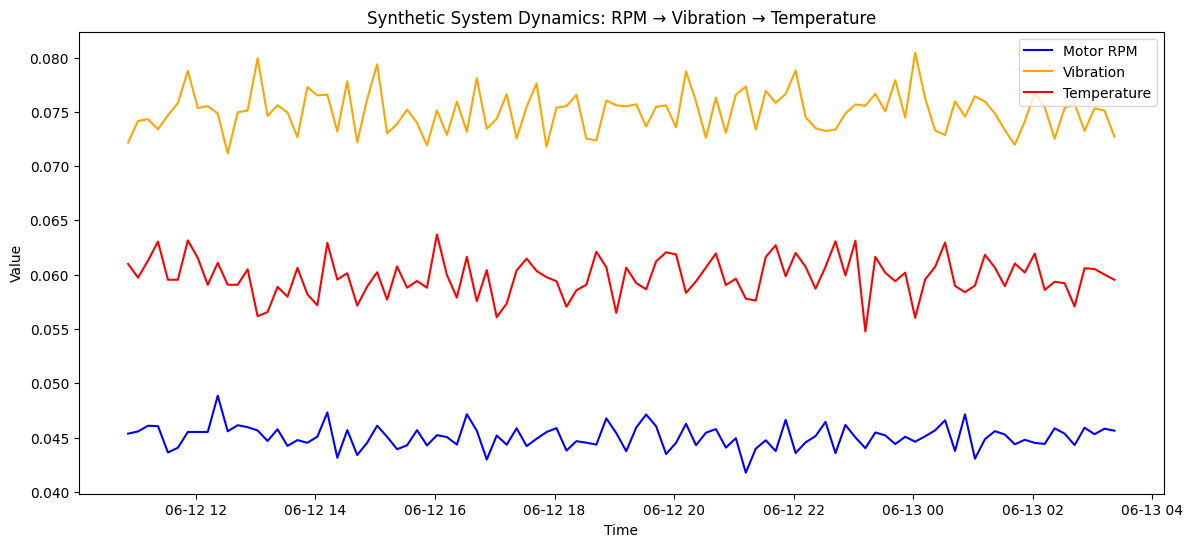

In [3]:
plt.figure(figsize=(14, 6))

plt.plot(df['timestamp'], motor_rpm, label='Motor RPM', color='blue')
plt.plot(df['timestamp'], vibration, label='Vibration', color='orange')
plt.plot(df['timestamp'], temperature, label='Temperature', color='red')

plt.title("Synthetic System Dynamics: RPM → Vibration → Temperature")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

The dataset thus generated is however quite basic. By this I mean that each variable is independent (which is generally not) and temporally coherence is not even introduced. We'll try doing this next. There are a few steps we can make for this:
1. Create smoother transitions between each day. (Temperature won't just randomly change with each instance, it would do so coherently).
2. Introduce dependencies between the variables. (Vibration and Temperature are coupled).
3. Add trends and seasonality. (Environmental effects, Motor warm up hrs etc.)

In [4]:
# BELOW IS A NAIVE APPROACH, IGNORE PLS
df.drop(columns=df.columns, inplace=True)

# For temperature let's start with some 
temperature = np.zeros(num_records)

# Initial value (location parameter i.e mean)
loc = 0.06
temperature[0] = loc

# Max deviation expected in 10 minutes
step_std = 0.0001
reversion_strength = 0.05 # Incase the temperature exceeds the mean a lot we want it to pull it back to not let system venture towards the extreme.

for t in range(1, num_records):
    pull_back = reversion_strength * (loc - temperature[t-1]) # If current temp is greater than normal temp, it will be negative else positive. A negative value will be decrease the overall temp and a positive value will be increase it.
    noise = np.random.normal(0, step_std)
    temperature[t] = temperature[t - 1] + pull_back + noise
    
# Now our equation as follows:
# temperature_t = temperature_{t-1} + noise

df['temperature'] = temperature
df.head()

,temperature
0,0.060000
1,0.059841
2,0.059789
3,0.059800
4,0.059814


We can reflect on the following arguments:
**Argument**: Motor RPM is the primary driver of the system. Everything else just reacts to it.
RPM is externally driven by the workers. It depends on the workload pressure (demand) thus seasonality. Therefore, paired with the timestamp column, it will form a time-series with seasonality, trends, and smooth transitions.
**Argument**: Vibration is a heavily-coupled column with Motor RPM.   
This is because raises as soon as the RPM is raised.
**Argument**: Temperature is coupled with the other columns as well however, it is slow to respond.
As vibrations increase, temperature will raise but gradually which indicates it has a strong inertia. 

Our previous approach was stupid because we started with temperature which determines nothing (however, we could have taken the reversed approach to construct other params based on temperature but it wouldn't have work)

So now the map will be as follows:

```markdown
        Motor RPM (fast, controllable)
        ↓
        Vibration (fast, reactive)
        ↓
        Temperature (slow, accumulative)
```


**How to model seasonality mathematically?**
Seasonality is a deterministic, repeating pattern in time. To encode, we need to consider that:
`f(t + P) for some period P = f(t)`
and we know such behavior is shown by the [sine wave](https://en.wikipedia.org/wiki/Sine_wave) as:

`sin(2πt / P)`

where, t is the time index, P is period i.e. number of steps after which pattern repeats and, 2π since value is repeated after a full cycle. 
So, the expression will start at 0, then raise to 1 and then fall to -1 - all smoothly - giving us the seasonality effect.
We will multiply it with a constant number to add to our base RPM to produce a seasonality effect. This number will be called as the **Seasonal Amplitude**.


In [5]:
df = pd.DataFrame()

num_days = 730
interval_minutes = 10

interval = pd.Timedelta(minutes=interval_minutes) 
steps_per_day = (24 * 60) // interval_minutes
num_records = num_days * steps_per_day

timestamps = [start_time + i * interval for i in range(num_records)]
df["timestamp"] = timestamps


In [6]:
# RPM
# First, rpm_t = rpm_{t-1} + small_adjustment [Inertia with gaussian noise]
# Second, rpm_t = baseline + seasonal_effect + trend [Seasonality]
# Third, rpm_t = rpm_{t-1} + control_strength × (target_rpm_t − rpm_{t-1}) + noise


motor_rpm = np.zeros(num_records)

base_rpm = 0.045
motor_rpm[0] = 0.045

# Parameters
rpm_noise_std = 0.004
control_strength = 0.1
seasonal_amplitude = 0.004
seasonal_period = steps_per_day*7 # weekly



for t in range(1, num_records):
    seasonal_effect = seasonal_amplitude * np.sin(2 * np.pi * t / seasonal_period) 
    target_rpm = base_rpm + seasonal_effect
    
    motor_rpm[t] = motor_rpm[t-1] + control_strength * (target_rpm - motor_rpm[t-1]) + np.random.normal(0, rpm_noise_std)
   
    
df['motor_rpm'] = motor_rpm

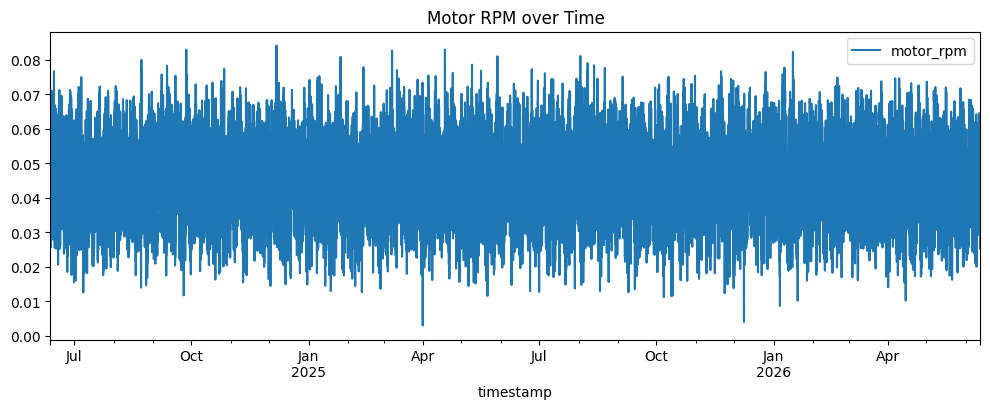

In [7]:
df.plot(x='timestamp', y='motor_rpm', title='Motor RPM over Time', figsize=(12, 4))
plt.show() # Without gaussian noise it was a nice smooth sine wave

`vibration_t = inertia * vibration_{t-1} + coupling * (rpm_t - base_rpm) + noise`

This relationship will show the coupled, highly-responsive, relationship between the rm and the coupling.
Parameters:   
Inertia: Vibration's inertia to remain at its previous measurment and not change.   
Coupling: How strongly RPM affects inertia.   
(rpm_t - base_rpm): Deviation that arises from the rpm change.   
Noise: Gaussian Noise.  

In [8]:
vibration = np.zeros(num_records)

base_vibration = 0.075
vibration[0] = base_vibration

vib_inertia = 0.8
rpm_coupling = 0.5
vib_noise_std = 0.0008

for t in range(1, num_records):
    vibration[t] = base_vibration + vib_inertia * (vibration[t-1] - base_vibration) + rpm_coupling * (motor_rpm[t] - base_rpm) + np.random.normal(0, vib_noise_std)
    
df['vibration'] = vibration

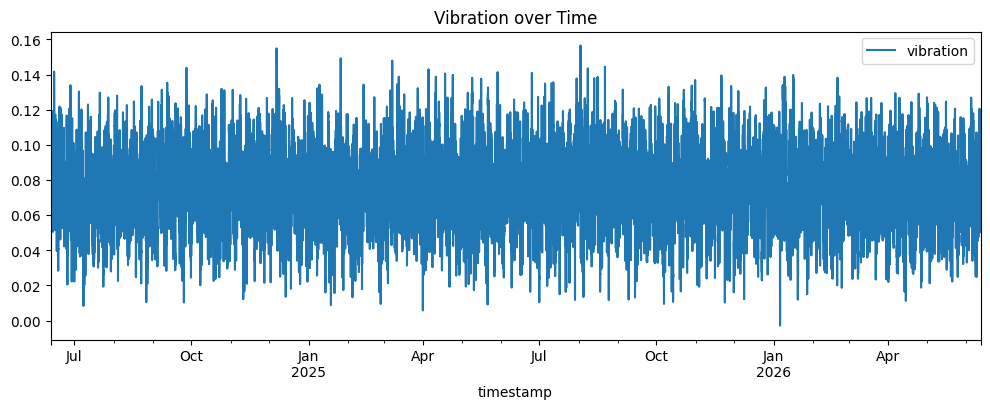

In [9]:
df.plot(x='timestamp', y='vibration', title='Vibration over Time', figsize=(12, 4))
plt.show() # we can notice that it responds to rpm however carries its own inertia as well

`temperature_t = inertia * temperature_{t-1} + coupling_vib * (vibration_t - base_vibration) + noise`

This is the equation we are looking for. 

Temperature will have its own inertia (to not change) + coupling with vibration and gaussian noise. Seems trivial compared to the journey we have undertaken till now.

In [10]:
temperature = np.zeros(num_records)
base_temp = 0.06 
temperature[0] = base_temp

temp_inertia = 0.9
coupling_vib = 0.5
temp_noise_std = 0.0003

for t in range(1, num_records):
    temperature[t] = base_temp + temp_inertia * (temperature[t-1] - base_temp) + coupling_vib * (vibration[t] - base_vibration) + np.random.normal(0, temp_noise_std)

df['temperature'] = temperature

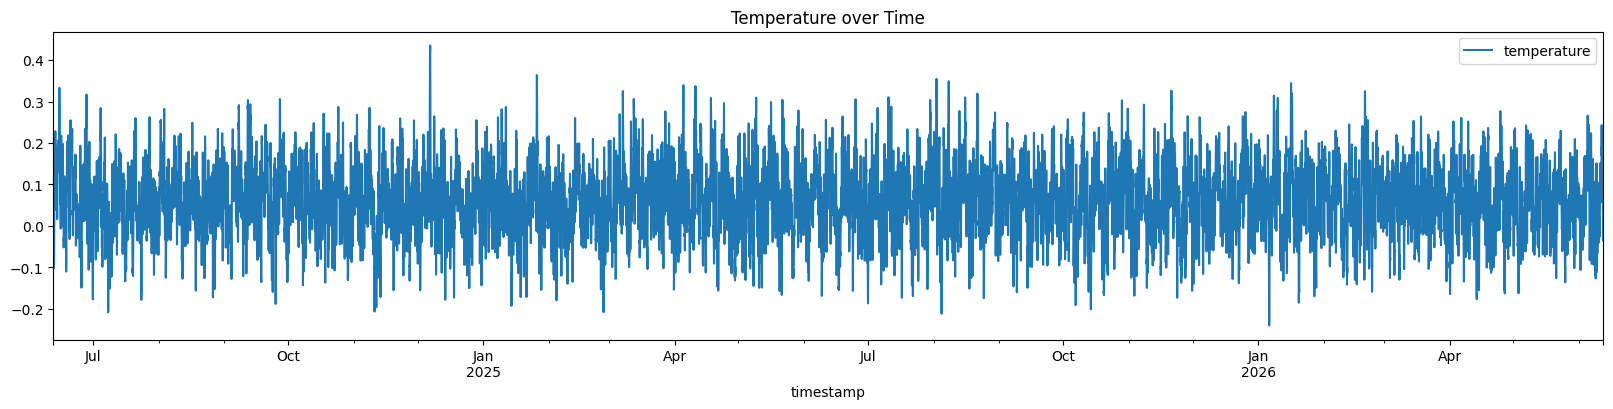

In [11]:
df.plot(x='timestamp', y='temperature', title='Temperature over Time', figsize=(20, 4))
plt.show() # we can notice that it responds sluggishly to rpm and carries its own inertia as well

Given this probably, we have our *Normal data* ready with us! Let us plot them altogether:

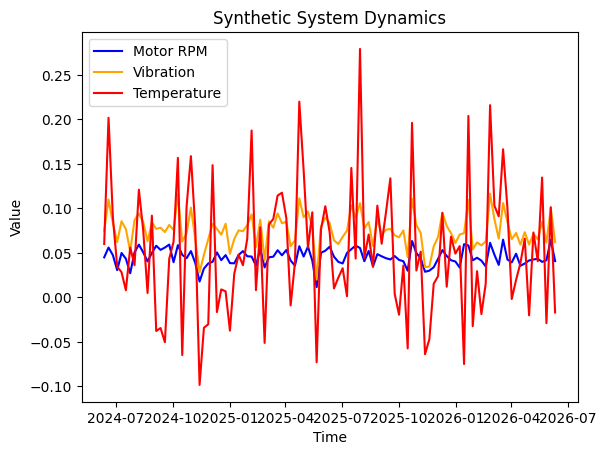

In [12]:
df_to_plot = df.iloc[::1008]
# plt.figure(figsize=(0,6))
plt.plot(df_to_plot['timestamp'], df_to_plot['motor_rpm'], label='Motor RPM', color='blue')
plt.plot(df_to_plot['timestamp'], df_to_plot['vibration'], label='Vibration', color='orange')
plt.plot(df_to_plot['timestamp'], df_to_plot['temperature'], label='Temperature', color='red')

plt.title("Synthetic System Dynamics")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()



***

## Anomalous Data
There can be three kinds of anomalies we can inject in our normal data:  

1. **Point anomalies**    
Single-time-step deviations   
Example: sudden spike in RPM, vibration, or temperature

2. **Contextual anomalies**   
Values that are unusual given the context   
Example: temperature low while vibration is high, or RPM high but vibration low

3. **Collective anomalies**   
Small strange deviations over multiple steps forming a pattern    
Note: Not doing rn   
Example: vibration slowly rising over 1 hour even though RPM is

In [13]:
df_normal = df.copy() # Copy of clean original data
df['anomaly'] = 0 

In [19]:
print(df.shape)
print(len(df))

(105120, 5)
105120


Below are **point anomalies** introduced. These are pure contextual breaks - They just spike randomly.

In [20]:
df.reset_index(drop=True, inplace=True)

df['anomaly'] = 0

# Point anomalies
idx = 1_000
df.iloc[idx, df.columns.get_loc('motor_rpm')] += 0.015
df.iloc[idx, df.columns.get_loc('anomaly')] = 1

idx = 3_200
df.iloc[idx, df.columns.get_loc('vibration')] += 0.02
df.iloc[idx, df.columns.get_loc('anomaly')] = 1

idx = 9_500
df.iloc[idx, df.columns.get_loc('temperature')] += 0.02
df.iloc[idx, df.columns.get_loc('anomaly')] = 1


Below are **contextual anomalies**. They represent wrong relationships.

In [21]:
# Motor-RPM is high while vibration is low
start = 4_000
end = start + 20

df.loc[start:end, 'motor_rpm'] += 0.01
df.loc[start:end, 'vibration'] -= 0.01
df.loc[start:end, 'anomaly'] = 1

# Vibration is high and temperature is low

start = 5_200
end = start + 50

df.loc[start:end, 'vibration'] += 0.01
df.loc[start:end, 'temperature'] -= 0.01
df.loc[start:end, 'anomaly'] = 1


In [24]:
# Save normal data
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

 
df.to_csv('./data/normal_data.csv.zip', index=False, compression='zip')
df.to_csv('./data/synthetic_data.csv.zip', index=False, compression='zip')